# IPLACEX

## Basic Analysis

Number of chats: 5830
Number of messages: 10490
Average messages per session: 1.80

Number of chats with administrative messages: 3063
Percentage of chats with administrative messages: 52.54%

Statistics after removing chats with administrative messages:
Number of educational chats: 2767
Number of educational messages: 5248
Average messages per session: 1.90


Number educational chats with more than 1 message: 1044
Percentage of chats with more than 1 message: 37.73%


Percentage of total educational chats: 17.91%


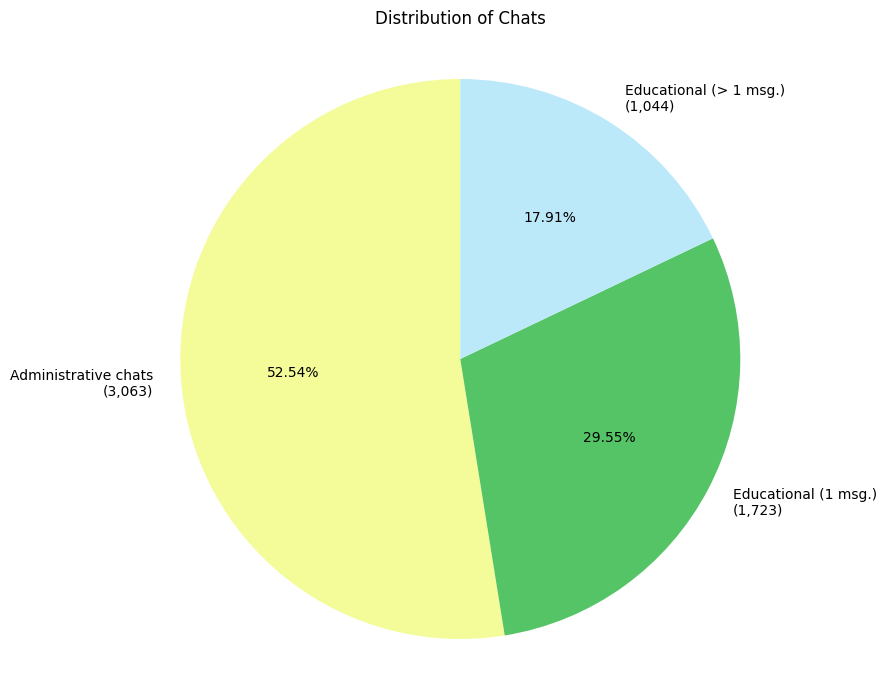

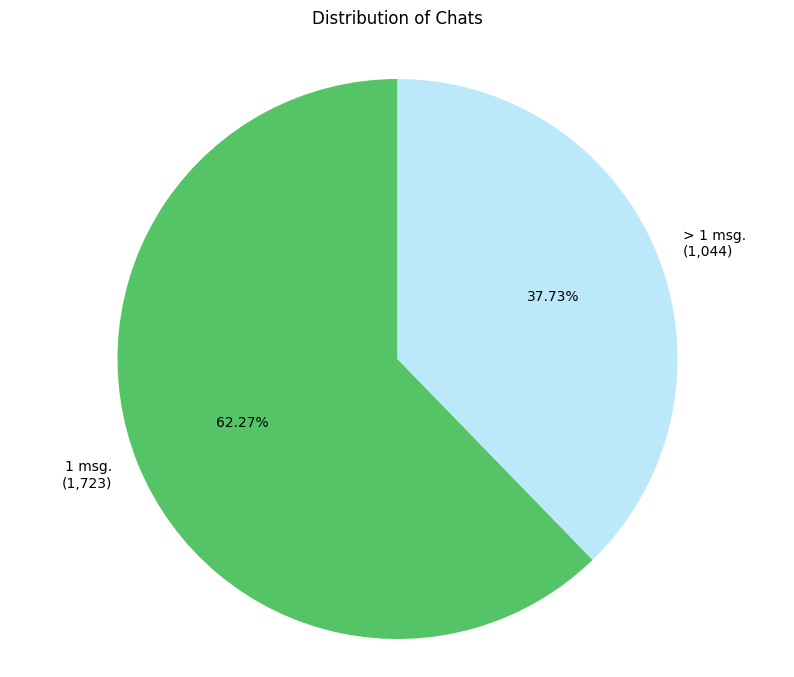

In [89]:
import pandas as pd
import matplotlib.pyplot as plt

# Try reading the CSV file and check the columns
df = pd.read_csv('data/temp/chats_delta.csv', sep=',', on_bad_lines='skip', header=0, encoding='utf-8-sig')

# Count the number of unique session_ids (chats)
chats = df['session_id'].nunique()
print(f"Number of chats: {chats}")

# Count the number of unique messages
messages = df['message_id'].nunique()
print(f"Number of messages: {messages}")

# Average number of messages per session
avg_messages = messages / chats
print(f"Average messages per session: {avg_messages:.2f}")

# Identify sessions that contain administrative messages
chats_admin = df[df['administrativa'] == 1]['session_id'].unique()
print(f"\nNumber of chats with administrative messages: {len(chats_admin)}")
# Percentage of chats with administrative messages
print(f"Percentage of chats with administrative messages: {len(chats_admin) / chats * 100:.2f}%")

# Remove sessions that contain administrative messages
df_edu = df[~df['session_id'].isin(chats_admin)]

#Sve the filtered dataset to a new CSV file
df_edu.to_csv('data/temp/chats_edu.csv', sep=',', index=False, encoding='utf-8-sig')

# Update statistics with the filtered dataset
chats_edu = df_edu['session_id'].nunique()
print("\nStatistics after removing chats with administrative messages:")
print(f"Number of educational chats: {chats_edu}")

messages_edu = df_edu['message_id'].nunique()
print(f"Number of educational messages: {messages_edu}")

avg_messages_edu = messages_edu / chats_edu
print(f"Average messages per session: {avg_messages_edu:.2f}")

# Check df_edu with chats with number of messages > 1
df_edu = df_edu[df_edu['session_id'].isin(df_edu['session_id'].value_counts()[df_edu['session_id'].value_counts() > 1].index)]
# Count the number of fields in the 'ESCUELA' column that are empty or contain only whitespace
empty_school_field = df_edu[df_edu['ESCUELA'].isnull() | (df_edu['ESCUELA'].astype(str).str.strip() == '')]['session_id'].nunique()
# Filter fields in the 'ESCUELA' column that are empty or contain only whitespace
df_edu = df_edu[~(df_edu['ESCUELA'].isnull() | (df_edu['ESCUELA'].astype(str).str.strip() == ''))]

print(f"\n\nNumber educational chats with more than 1 message: {df_edu['session_id'].nunique()}")


# Percentage of chats with more than 1 message
print(f"Percentage of chats with more than 1 message: {df_edu['session_id'].nunique() / chats_edu * 100:.2f}%")

# Percent od educational chats
print(f"\n\nPercentage of total educational chats: {df_edu['session_id'].nunique() / chats * 100:.2f}%")



# Create arrays for the pie chart
labels = ['Administrative chats', 'Educational (1 msg.)', 'Educational (> 1 msg.) ']
sizes = [len(chats_admin), chats_edu - df_edu['session_id'].nunique(), df_edu['session_id'].nunique()]
# Add absolute numbers to labels
labels = [f'{label}\n({size:,})' for label, size in zip(labels, sizes)]

# Colors for each section
colors = ["#F4FC99", "#55C466", "#BCE9FA"]

fig, ax = plt.subplots(figsize=(10, 8))
wedges, texts, autotexts = plt.pie(sizes, labels=labels, colors=colors, autopct='%1.2f%%', startangle=90)

# Add a title
plt.title('Distribution of Chats', pad=20)

plt.axis('equal')
plt.show()

# Create arrays for the pie chart showing only educational chats
labels = ['1 msg.', '> 1 msg.']
sizes = [chats_edu - df_edu['session_id'].nunique(), df_edu['session_id'].nunique()]
# Add absolute numbers to labels
labels = [f'{label}\n({size:,})' for label, size in zip(labels, sizes)]

# Colors for each section
colors = ["#55C466", "#BCE9FA"]

fig, ax = plt.subplots(figsize=(10, 8))
wedges, texts, autotexts = plt.pie(sizes, labels=labels, colors=colors, autopct='%1.2f%%', startangle=90)

# Add a title
plt.title('Distribution of Chats', pad=20)

plt.axis('equal')
plt.show()





## Analysis of School

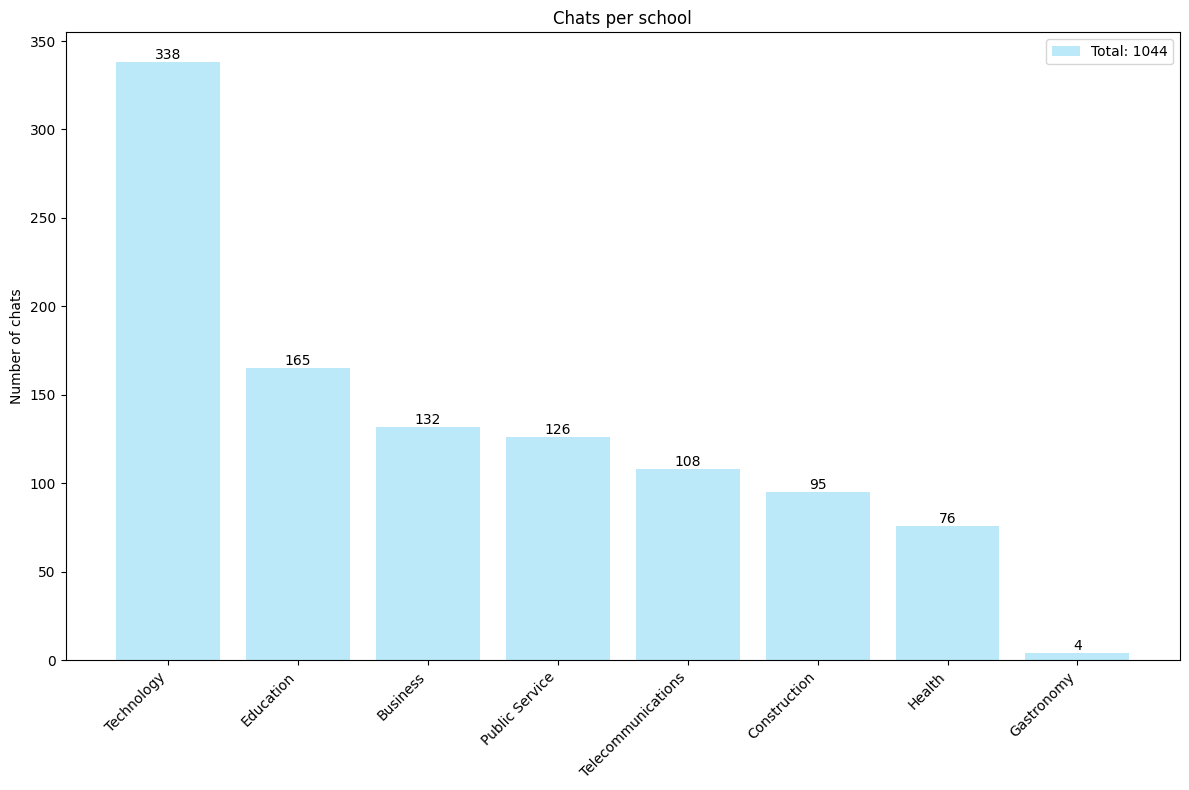

In [90]:
# Count the number of messages per school and session
schools_sessions = df_edu.groupby(['session_id', 'ESCUELA']).size().reset_index(name='num_messages')

# Filter out sessions with only 1 message
schools_sessions = schools_sessions[schools_sessions['num_messages'] > 1]

# Calculate the number of sessions per school
sessions_per_school = schools_sessions.groupby('ESCUELA')['session_id'].nunique().reset_index(name='num_sessions')

# Plot the number of sessions per school

# Ordenar por número de sesiones descendente antes de graficar
sessions_per_school_sorted = sessions_per_school.sort_values(by='num_sessions', ascending=False)

# Mapeamento dos nomes das escolas para inglês
school_name_map = {
    'ESCUELA DE ADMINISTRACIÓN Y NEGOCIOS': 'Business',
    'ESCUELA DE CONSTRUCCIÓN': 'Construction',
    'ESCUELA DE DESARROLLO SOCIAL Y SERVICIO PÚBLICO': 'Public Service',
    'ESCUELA DE EDUCACIÓN': 'Education',
    'ESCUELA DE GASTRONOMÍA': 'Gastronomy',
    'ESCUELA DE INFORMÁTICA Y TELECOMUNICACIONES': 'Telecommunications',
    'ESCUELA DE SALUD': 'Health',
    'ESCUELA DE TECNOLOGÍA': 'Technology'
}

# Aplica o mapeamento para criar uma nova coluna com o nome em inglês
sessions_per_school_sorted['School_EN'] = sessions_per_school_sorted['ESCUELA'].map(school_name_map)

plt.figure(figsize=(12, 8))  # aumenta o tamanho vertical
bars = plt.bar(
    sessions_per_school_sorted['School_EN'],
    sessions_per_school_sorted['num_sessions'],
    color="#BCE9FA"
)
plt.xlabel('')
plt.ylabel('Number of chats')
plt.title('Chats per school')
plt.xticks(rotation=45, ha='right', fontsize=10)
# Adiciona o número em cima de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}', ha='center', va='bottom', fontsize=10)
total_sessions = sessions_per_school_sorted['num_sessions'].sum()
plt.legend([f'Total: {total_sessions}'])
plt.tight_layout()
plt.show()

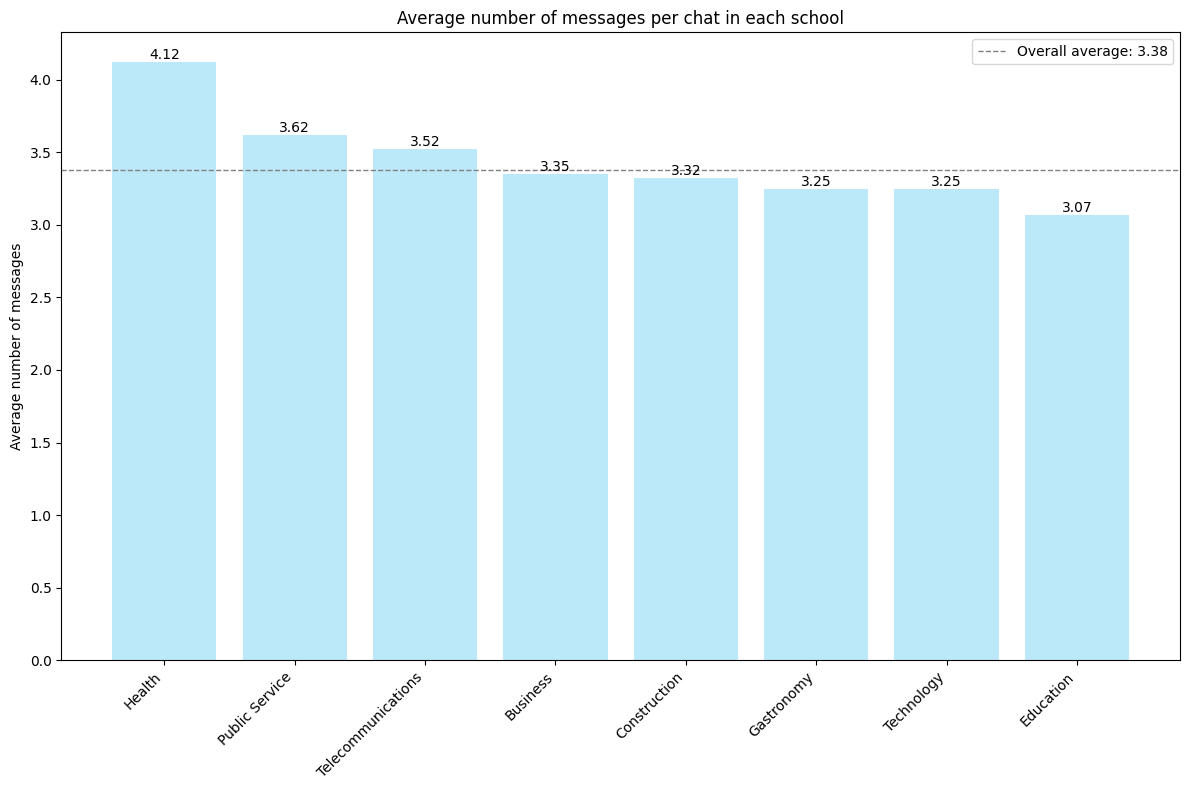

In [91]:
# Count the number of messages per school and session
schools_messages = df_edu.groupby(['session_id', 'ESCUELA']).size().reset_index(name='num_messages')

# Filter out sessions with only 1 message
schools_messages = schools_messages[schools_messages['num_messages'] > 1]

# Calculate the average number of messages per session per school
avg_messages_per_school = schools_messages.groupby('ESCUELA')['num_messages'].mean().round(2).reset_index(name='avg_messages')

# Ordenar por promedio de mensajes descendente antes de graficar
avg_messages_per_school_sorted = avg_messages_per_school.sort_values(by='avg_messages', ascending=False)

# Aplicar o mapeamento para nomes em inglês
avg_messages_per_school_sorted['School_EN'] = avg_messages_per_school_sorted['ESCUELA'].map(school_name_map)

# Calcular a média geral correta (total de mensagens / total de sessões)
total_messages = schools_messages['num_messages'].sum()
total_sessions = schools_messages['session_id'].nunique()
correct_total_avg = (total_messages / total_sessions).round(2)

# Plot
plt.figure(figsize=(12, 8))
bars = plt.bar(
    avg_messages_per_school_sorted['School_EN'],
    avg_messages_per_school_sorted['avg_messages'],
    color="#BCE9FA"
)
plt.xlabel('')
plt.ylabel('Average number of messages')
plt.title('Average number of messages per chat in each school')
plt.xticks(rotation=45, ha='right', fontsize=10)
# Adiciona o número em cima de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.2f}', ha='center', va='bottom', fontsize=10)
plt.axhline(y=correct_total_avg, color='grey', linestyle='--', linewidth=1, label=f'Overall average: {correct_total_avg:.2f}')
plt.legend()
plt.tight_layout()
plt.show()



In [92]:
# Agrupamento de cursos em áreas
area_map = {
    'Escuela de Gastronomía': 'Health Sciences',
    'Escuela de Salud': 'Health Sciences',
    'Escuela de Construcción': 'Engineering and Technology',
    'Escuela de Tecnología': 'Engineering and Technology',
    'Escuela de Informática y Telecomunicaciones': 'Engineering and Technology',
    'Escuela de Desarrollo Social y Servicio Público': 'Social Sciences and Humanities',
    'Escuela de Educación': 'Social Sciences and Humanities',
    'Escuela de Administración y Negocios': 'Business and Administration'
}